In [1]:
import pandas as pd

In [2]:
fake_df=pd.read_csv('/Fake.csv')
real_df=pd.read_csv('/True.csv')

In [3]:
fake_df = fake_df.head(100)
real_df = real_df.head(100)

In [4]:
fake_df['label'] = 1
real_df['label'] = 0

In [5]:
# Combine datasets using concat
combined_df = pd.concat([fake_df, real_df], axis=0)

# Shuffle the combined dataset
# reset_index drops the old index and creates a new one
combined_df = combined_df.sample(frac=1).reset_index(drop=True)

In [6]:
combined_df.head()

,title,text,subject,date,label
0,Democrat wins by one vote in Virginia legislat...,(Corrects spelling of Virginia House of Deleg...,politicsNews,"December 19, 2017",0
1,Failed vote to oust president shakes up Peru's...,LIMA (Reuters) - Peru’s President Pedro Pablo ...,politicsNews,"December 23, 2017",0
2,"Trump on Twitter (Dec 22) - Tax cut, Missile d...",The following statements were posted to the ve...,politicsNews,"December 22, 2017",0
3,Sources Confirm Robert Mueller’s Office Inter...,"Jared Kushner, senior White House adviser and ...",News,"November 30, 2017",1
4,"Banks, healthcare service firms among winners ...",NEW YORK (Reuters) - Sweeping U.S. tax legisla...,politicsNews,"December 19, 2017",0


In [9]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Join tokens back into text
    return ' '.join(tokens)

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

combined_df['text'] = combined_df['text'].apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Create count vectorizer object
cv = CountVectorizer()

# Transform text data into document-term matrix
X = cv.fit_transform(combined_df['text'])

# Create target variable
y = combined_df['label']

In [11]:
#split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

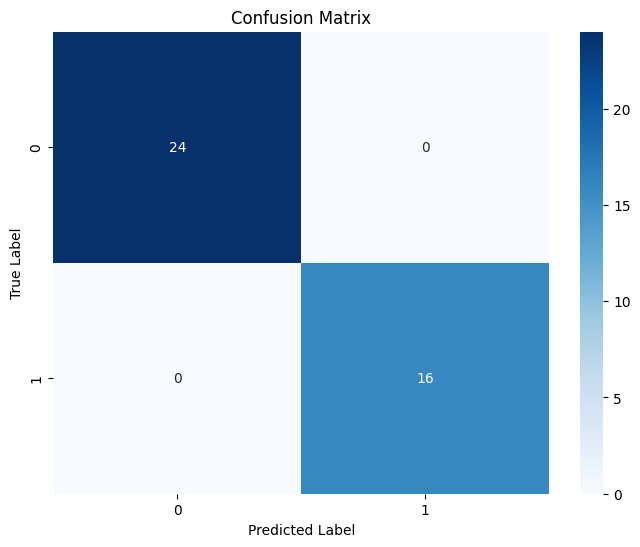


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        16

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import matplotlib.pyplot as plt

# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

In [13]:
def predict_news(text):
    # Clean the text using the previously defined clean_text function
    cleaned_text = clean_text(text)

    # Transform the text using the fitted CountVectorizer
    text_vector = cv.transform([cleaned_text])

    # Make prediction using the trained Random Forest model
    prediction = rf_model.predict(text_vector)[0]
    probability = rf_model.predict_proba(text_vector)[0]

    # Return result with probability
    if prediction == 0:
        return f"This is likely REAL news (Confidence: {probability[0]:.2%})"
    else:
        return f"This is likely FAKE news (Confidence: {probability[1]:.2%})"

In [14]:
predict_news("Donald Trump s administration finds new ways to look foolish on a daily basis, and Trump s staff is more than willing to pick up the slack whenever their boss isn t behaving like a big enough idiot.On Friday, Trump s acting assistant administrator for Asia, Gloria Steele, made sure that she humiliated America and the Trump administration when she was left uncomfortably speechless by a simple question about climate change. The question was asked by Rep. Gerry Connolly (D-VA), who wanted to know if climate change has  anything at all to do with  rising sea levels in reference to the massive flooding in Bangladesh. Connolly asked Steele: Could the fact that a third of an entire sovereign nation Bangladesh being under water, could it have anything at all to do with, I don t know, the warming of the climate? Just like most of the incompetent people staffed on Trump s administration, Steele doesn t know a damn thing about the position she s in. Steele was obviously unprepared to answer any real questions about the matter, because all she could do was smile and let her mouth hang open as she was left clueless and speechless. This is an absolutely inappropriate response to a simple, straightforward question, but Steele could do no better.It turns out that Steele is taking after her boss in being completely ignorant. Trump himself has called climate change a  hoax  many times, and has even blamed the Chinese for being responsible for its creation. Trump s denial of facts and evidence on climate change is so dangerous that he made the United States one of the only three countries to oppose the Paris Climate Agreement. The stupidity of Trump and his administration are major threats to the future of the climate, and it s clear that they don t have any of the answers that the planet needs. You can watch Steele go completely mute below:Featured image via Alex Wong/Getty Images")

'This is likely FAKE news (Confidence: 80.00%)'